## Step 1) Run the script below to count tokens
```bash
!bash .scripts/count_tokens.sh
```
**Note**: if you run the count_tokens script multiple times, you should clear the existing output json files in `results/counts` folder first

## Step 2) Analyse

In [13]:
# analysis.ipynb
import json
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# 1. Load all jsonl
# -----------------
dataset_split = "test"  # 'dev' or 'full' (for train+dev together)
max_input_length = 2048  # 512, 1024, 2048
base_dir = pathlib.Path(f"results/counts_{dataset_split}_{max_input_length}/")
records = []
for l_dir in base_dir.iterdir():
    if not l_dir.is_dir():
        continue
    lang = l_dir.name.lower()
    for schema_dir in l_dir.iterdir():
        if not schema_dir.is_dir():
            continue
        schema_type = schema_dir.name
        for file in schema_dir.glob("*.jsonl"):
            with file.open("r", encoding="utf-8") as f:
                for line in f:
                    rec = json.loads(line)
                    rec["lang"] = lang
                    rec["schema"] = schema_type
                    records.append(rec)

df = pd.DataFrame(records)
print(f'{len(df[df["truncated_tokens"] > 0])}/{len(df)}')

# -----------------
# 2. Rename schema types for readability
# -----------------
schema_labels = {
    "compact": "Full Compact",
    "norange": "No Range",
    "peteshaw": "No Range",
    "none": "No Schema"
}
df["schema_label"] = df["schema"].map(schema_labels).fillna(df["schema"])

languages = ["sparql", "sql", "cypher"]
colors = {
    "sparql": "#2F7B3B",
    "sql": "#BCAE55",
    "cypher": "#51779C",
}

0/19323


In [14]:
# -----------------
# 7. Token length and truncation distribution
# -----------------

# Compute per-sample truncation ratio
df["trunc_ratio_sample"] = df["truncated_tokens"] / df["token_count"]
# print(df[df["truncated_tokens"] > 0]["trunc_ratio_sample"])
# print(len(df[df["truncated_tokens"] > 0]))
# print(len(df))

# Drop NaNs that may result from 0 token_count
df = df.dropna(subset=["trunc_ratio_sample"])

print(len(df))


19323


,lang,schema_label,mean_token_len,std_token_len,var_token_len,mean_trunc_ratio,std_trunc_ratio,var_trunc_ratio,longer_than_512,longer_than_1024,longer_than_2048
0,cypher,Full Compact,405.551933,286.730783,82214.541920,0.0,0.0,0.0,533,148,0
1,cypher,No Range,299.373079,222.855785,49664.700915,0.0,0.0,0.0,308,0,0
2,cypher,No Schema,28.655333,5.949811,35.400255,0.0,0.0,0.0,0,0,0
3,sparql,Full Compact,230.619003,160.329368,25705.506218,0.0,0.0,0.0,148,0,0
4,sparql,No Range,160.271076,118.118593,13952.001973,0.0,0.0,0.0,72,0,0
5,sparql,No Schema,28.655333,5.949811,35.400255,0.0,0.0,0.0,0,0,0
6,sql,Full Compact,245.585934,179.453147,32203.431918,0.0,0.0,0.0,148,0,0
7,sql,No Range,161.767583,123.232569,15186.266087,0.0,0.0,0.0,78,0,0
8,sql,No Schema,21.421053,5.416285,29.336146,0.0,0.0,0.0,0,0,0


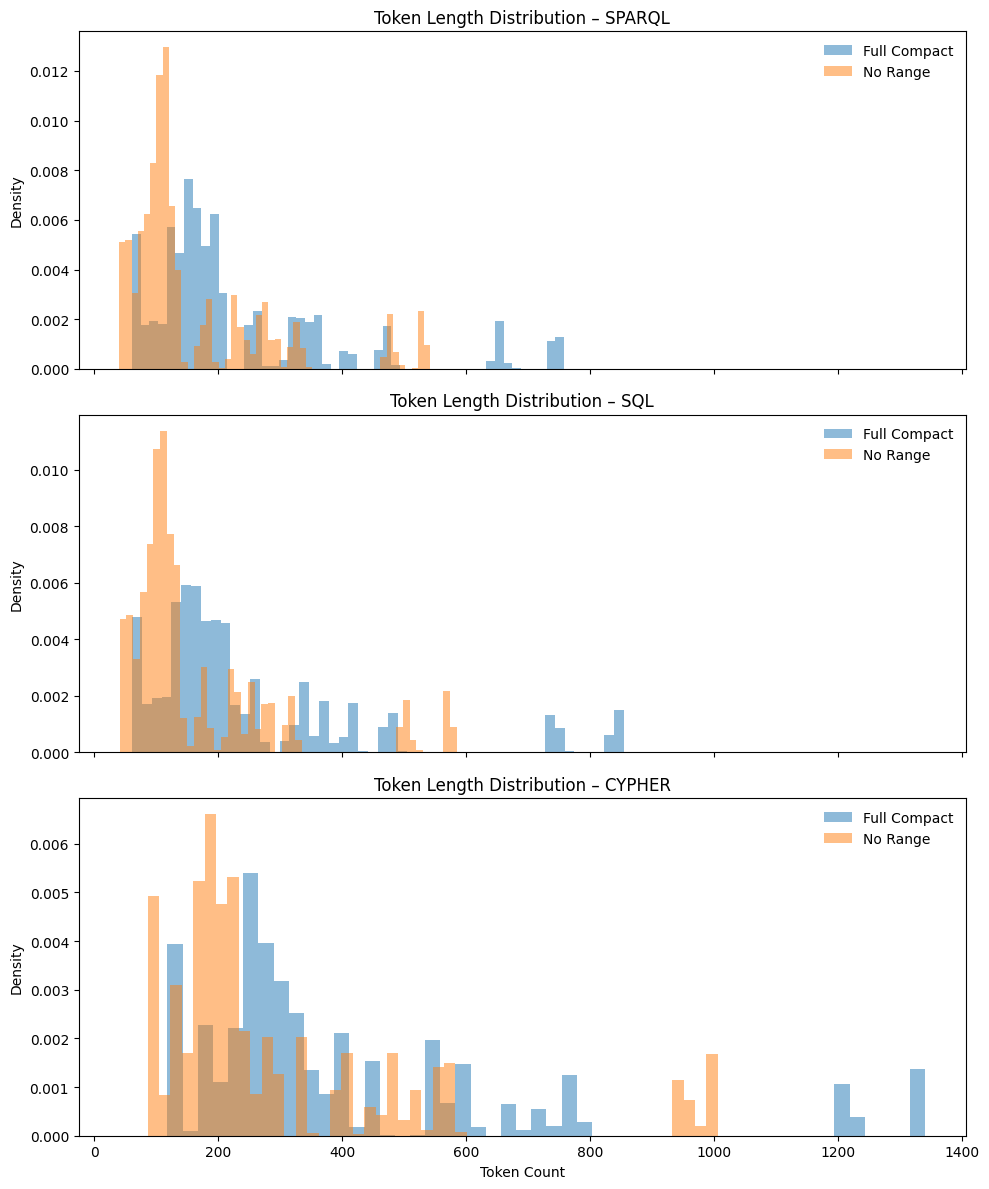

/home/vejvar-martin-nj/git/uT5-ssc/.conda/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


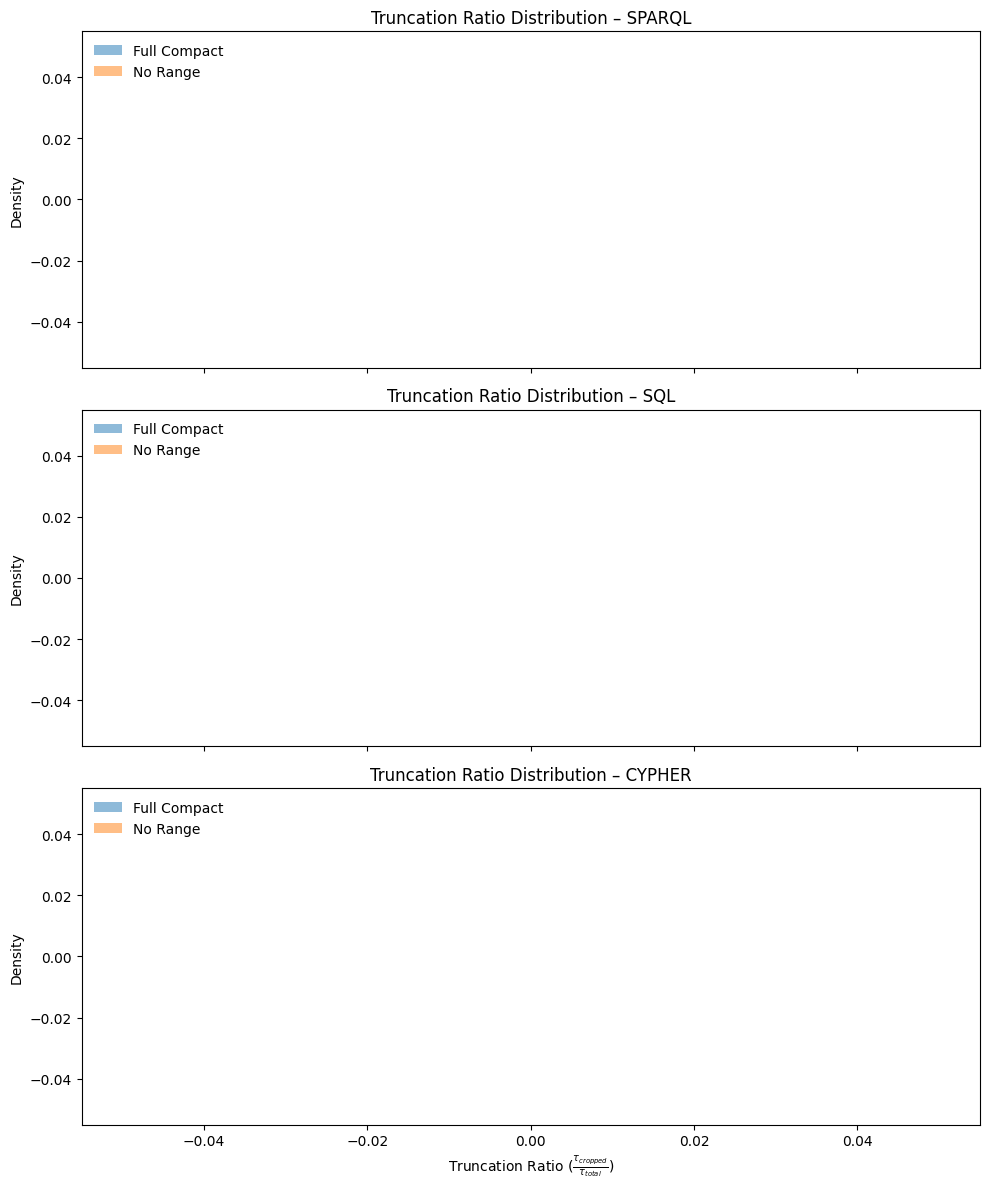

,lang,schema_label,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage,Sample_Size
0,cypher,Full Compact,243.0,454.5,211.5,-74.25,771.75,198,9.222170,2147
1,cypher,No Range,172.0,341.5,169.5,-82.25,595.75,148,6.893340,2147
2,cypher,No Schema,24.0,32.0,8.0,12.00,44.00,36,1.676758,2147
3,sparql,Full Compact,135.0,269.5,134.5,-66.75,471.25,185,8.616674,2147
4,sparql,No Range,90.0,193.5,103.5,-65.25,348.75,148,6.893340,2147
5,sparql,No Schema,24.0,32.0,8.0,12.00,44.00,36,1.676758,2147
6,sql,Full Compact,141.0,272.5,131.5,-56.25,469.75,209,9.734513,2147
7,sql,No Range,90.0,189.5,99.5,-59.25,338.75,148,6.893340,2147
8,sql,No Schema,18.0,25.0,7.0,7.50,35.50,36,1.676758,2147


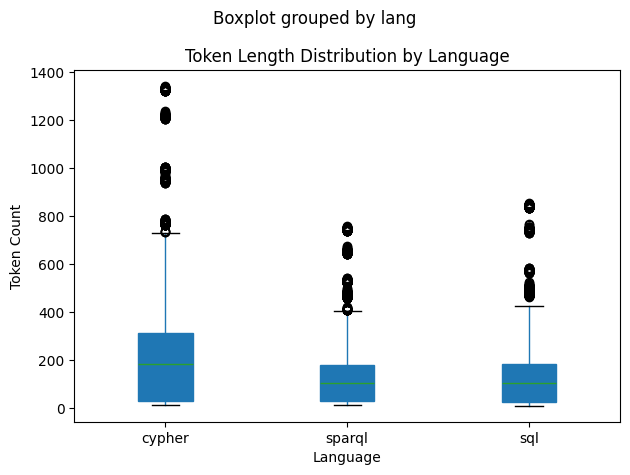

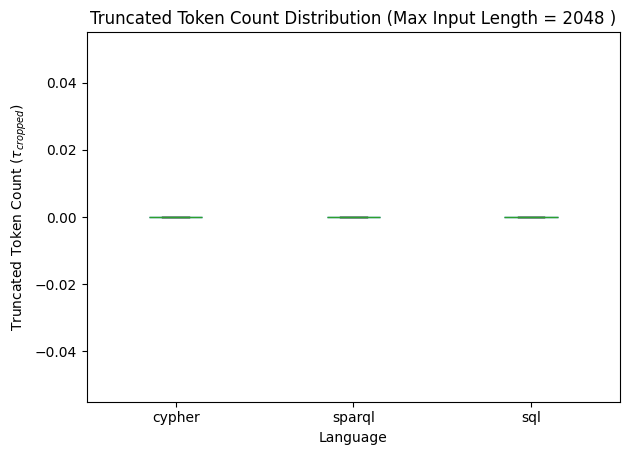

In [15]:
schemas = ["Full Compact", "No Range"]  # df["schema_label"].unique()

# -----------------
# 7.1 Compute summary stats (mean, std, variance)
# -----------------
summary_stats = (
    df.groupby(["lang", "schema_label"])
    .agg(
        mean_token_len=("token_count", "mean"),
        std_token_len=("token_count", "std"),
        var_token_len=("token_count", "var"),
        mean_trunc_ratio=("trunc_ratio_sample", "mean"),
        std_trunc_ratio=("trunc_ratio_sample", "std"),
        var_trunc_ratio=("trunc_ratio_sample", "var"),
        longer_than_512=("token_count", lambda x: (x > 512).sum()),
        longer_than_1024=("token_count", lambda x: (x > 1024).sum()),
        longer_than_2048=("token_count", lambda x: (x > 2048).sum()),

    )
    .reset_index()
)

display(summary_stats)

# Save stats
summary_stats.to_csv(base_dir.joinpath("token_trunc_distribution_stats.csv"), index=False)

# -----------------
# 7.2 Plot distribution of token lengths
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["token_count"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Token Length Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel("Token Count")
plt.tight_layout()
plt.savefig(base_dir.joinpath("token_length_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3 Plot distribution of truncation ratio
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    subset = subset[subset["truncated_tokens"] > 0]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["trunc_ratio_sample"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Truncation Ratio Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel(r"Truncation Ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")
plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_ratio_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers) per language & schema
# -----------------
boxplot_stats = []

for (lang, schema), subset in df.groupby(["lang", "schema_label"]):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "schema_label": schema,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset),
        "Sample_Size": len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save results
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats_by_schema.csv"), index=False)


# -----------------
# 7.4 Boxplots for variance visualization
# -----------------
fig, ax = plt.subplots(1, 1)

# Token length boxplot
# df[df["schema_label"] == "Full Compact"].boxplot(column="token_count", by="lang", ax=ax[0], grid=False, patch_artist=True)
df.boxplot(column="token_count", by="lang", ax=ax, grid=False, patch_artist=True)
ax.set_title("Token Length Distribution by Language")
ax.set_xlabel("Language")
ax.set_ylabel("Token Count")

plt.tight_layout()
plt.savefig(base_dir.joinpath("boxplots_token_counts.png"), dpi=300)
plt.savefig(base_dir.joinpath("boxplots_token_counts.svg"))
plt.savefig(base_dir.joinpath("boxplots_token_counts.pdf"))
plt.show()

fig, ax = plt.subplots(1, 1)

# Truncated token count boxplot (only for truncated samples)
df.boxplot(column="truncated_tokens", by="lang", ax=ax, grid=False, patch_artist=True)
ax.set_title(f"Truncated Token Count Distribution (Max Input Length = {max_input_length} )")
ax.set_xlabel("Language")
ax.set_ylabel(r"Truncated Token Count ($\tau_{cropped}$)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(base_dir.joinpath("boxplots_token_truncations.png"), dpi=300)
plt.savefig(base_dir.joinpath("boxplots_token_truncations.svg"))
plt.savefig(base_dir.joinpath("boxplots_token_truncations.pdf"))
plt.show()

In [16]:
# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers)
# -----------------
boxplot_stats = []

for lang, subset in df.groupby("lang"):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save to CSV
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats.csv"), index=False)

,lang,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage
0,cypher,32.0,312.0,280.0,-388.0,732.0,380,5.899705
1,sparql,32.0,182.0,150.0,-193.0,407.0,401,6.225741
2,sql,25.0,186.0,161.0,-216.5,427.5,376,5.837603



### Truncation Count Distribution Summary (Outliers Removed) ###
Removed 0 outliers from 19323 samples total.


/tmp/ipykernel_1504789/314864502.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))


,lang,schema_label,mean_trunc_count,std_trunc_count,count
0,cypher,Full Compact,0.0,0.0,2147
1,cypher,No Range,0.0,0.0,2147
2,cypher,No Schema,0.0,0.0,2147
3,sparql,Full Compact,0.0,0.0,2147
4,sparql,No Range,0.0,0.0,2147
5,sparql,No Schema,0.0,0.0,2147
6,sql,Full Compact,0.0,0.0,2147
7,sql,No Range,0.0,0.0,2147
8,sql,No Schema,0.0,0.0,2147



### Mean Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,0.0,0.0,0.0
No Range,0.0,0.0,0.0
No Schema,0.0,0.0,0.0



### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,0.0,0.0,0.0
No Range,0.0,0.0,0.0
No Schema,0.0,0.0,0.0


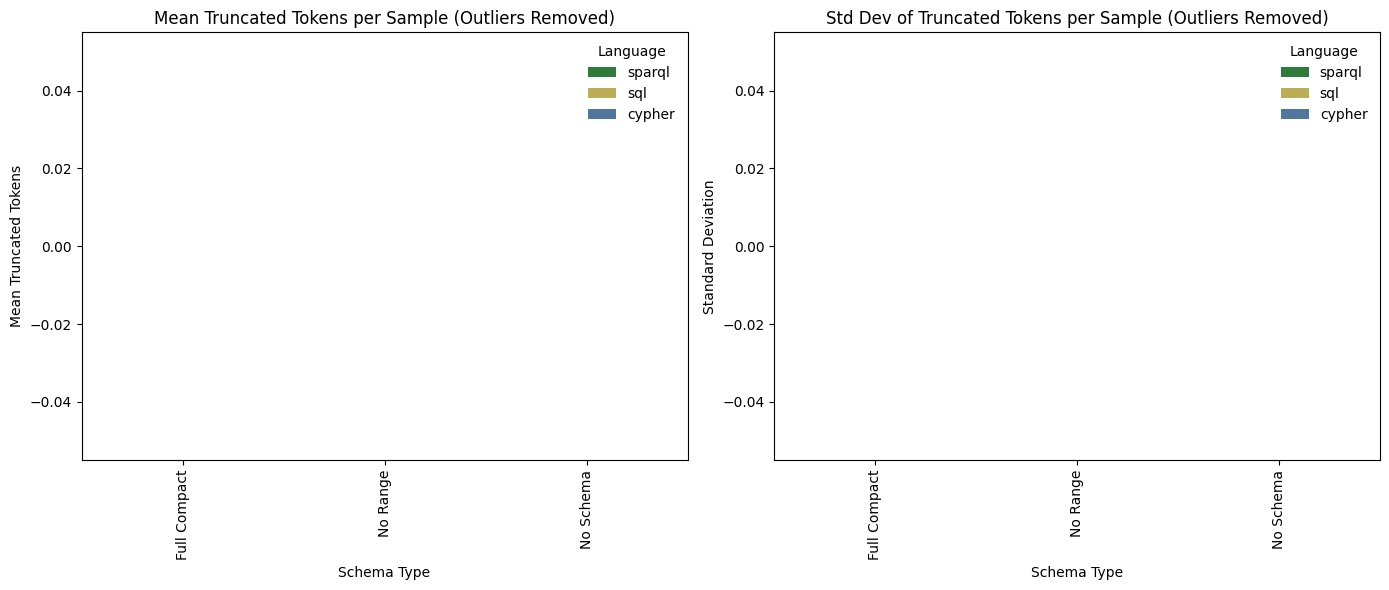

In [17]:
# -----------------
# 7.5 Truncation Count Distribution Analysis (with outlier removal)
# -----------------
print("\n### Truncation Count Distribution Summary (Outliers Removed) ###")

def remove_outliers_iqr(group, column):
    """Remove outliers from a DataFrame group using IQR."""
    Q1 = group[column].quantile(0.1)
    Q3 = group[column].quantile(0.9)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group[column] >= lower) & (group[column] <= upper)]

# Apply outlier removal per (lang, schema_label)
df_filtered = (
    df.groupby(["lang", "schema_label"], group_keys=False)
      .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))
)

print(f"Removed {len(df) - len(df_filtered)} outliers from {len(df)} samples total.")

# Compute mean and std after outlier removal
trunc_stats = (
    df_filtered.groupby(["lang", "schema_label"])
    .agg(
        mean_trunc_count=("truncated_tokens", "mean"),
        std_trunc_count=("truncated_tokens", "std"),
        count=("truncated_tokens", "size")
    )
    .reset_index()
)

display(trunc_stats)

# Pivot tables for mean and std
pivot_mean_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="mean_trunc_count")
pivot_std_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="std_trunc_count")

# Enforce consistent order
pivot_mean_trunc = pivot_mean_trunc.loc[:, languages]
pivot_std_trunc = pivot_std_trunc.loc[:, languages]

print("\n### Mean Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_mean_trunc)

print("\n### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_std_trunc)

# Save to CSV
pivot_mean_trunc.to_csv(base_dir.joinpath("trunc_count_mean_pivot_clean.csv"))
pivot_std_trunc.to_csv(base_dir.joinpath("trunc_count_std_pivot_clean.csv"))

# -----------------
# 7.6 Optional: Visualize mean and std of truncation counts
# -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean bar plot
pivot_mean_trunc.plot.bar(ax=axes[0], color=[colors.get(lang, "#999999") for lang in pivot_mean_trunc.columns])
axes[0].set_title("Mean Truncated Tokens per Sample (Outliers Removed)")
axes[0].set_xlabel("Schema Type")
axes[0].set_ylabel("Mean Truncated Tokens")
axes[0].legend(title="Language", frameon=False)

# Std bar plot
pivot_std_trunc.plot.bar(ax=axes[1], color=[colors.get(lang, "#999999") for lang in pivot_std_trunc.columns])
axes[1].set_title("Std Dev of Truncated Tokens per Sample (Outliers Removed)")
axes[1].set_xlabel("Schema Type")
axes[1].set_ylabel("Standard Deviation")
axes[1].legend(title="Language", frameon=False)

plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_count_summary_clean.png"), dpi=300)
plt.show()

# Token count examples

In [6]:
input_sql = "(sql) Count the number of stores the chain South has. | department_store | addresses : address_id (number) , address_details (text) | staff : staff_id (number) , staff_gender (text) , staff_name (text) | suppliers : supplier_id (number) , supplier_name (text) , supplier_phone (text) | department_store_chain : dept_store_chain_id (number) , dept_store_chain_name (text) | customers : customer_id (number) , payment_method_code (text) , customer_code (text) , customer_name (text) , customer_address (text) , customer_phone (text) , customer_email (text) | products : product_id (number) , product_type_code (text) , product_name (text) , product_price (number) | supplier_addresses : supplier_id (supplier_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_addresses : customer_id (customer_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_orders : order_id (number) , customer_id (customer_id) , order_status_code (text) , order_date (time) | department_stores : dept_store_id (number) , dept_store_chain_id (dept_store_chain_id) , store_name (text) , store_address (text) , store_phone (text) , store_email (text) | departments : department_id (number) , dept_store_id (dept_store_id) , department_name (text) | order_items : order_item_id (number) , order_id (order_id) , product_id (product_id) | product_suppliers : product_id (product_id) , supplier_id (supplier_id) , date_supplied_from (time) , date_supplied_to (time) , total_amount_purchased (text) , total_value_purchased (number) | staff_department_assignments : staff_id (staff_id) , department_id (department_id) , date_assigned_from (time) , job_title_code (text) , date_assigned_to (time)"
input_sparql = "(sparql) Count the number of stores the chain South has. | department_store | customer_orders: order_status_code (string) , order_id (integer) , order_date (dateTime) , customer_id (integer) , CUSTOMER_ID (customers) | department_store_chain: dept_store_chain_name (string) , dept_store_chain_id (integer) | departments: dept_store_id (integer) , department_name (string) , department_id (integer) , DEPT_STORE_ID (department_stores) | staff_department_assignments: staff_id (integer) , job_title_code (string) , department_id (integer) , date_assigned_to (dateTime) , date_assigned_from (dateTime) , STAFF_ID (staff) , DEPARTMENT_ID (departments) | supplier_addresses: supplier_id (integer) , date_to (dateTime) , date_from (dateTime) , address_id (integer) , SUPPLIER_ID (suppliers) , ADDRESS_ID (addresses) | suppliers: supplier_phone (string) , supplier_name (string) , supplier_id (integer) | department_stores: store_phone (string) , store_name (string) , store_email (string) , store_address (string) , dept_store_id (integer) , dept_store_chain_id (integer) , DEPT_STORE_CHAIN_ID (department_store_chain) | staff: staff_name (string) , staff_id (integer) , staff_gender (string) | customers: payment_method_code (string) , customer_phone (string) , customer_name (string) , customer_id (integer) , customer_email (string) , customer_code (string) , customer_address (string) | customer_addresses: date_to (dateTime) , date_from (dateTime) , customer_id (integer) , address_id (integer) , CUSTOMER_ID (customers) , ADDRESS_ID (addresses) | product_suppliers: total_value_purchased (decimal) , total_amount_purchased (string) , supplier_id (integer) , product_id (integer) , date_supplied_to (dateTime) , date_supplied_from (dateTime) , SUPPLIER_ID (suppliers) , PRODUCT_ID (products) | products: product_type_code (string) , product_price (decimal) , product_name (string) , product_id (integer) | order_items: product_id (integer) , order_item_id (integer) , order_id (integer) , PRODUCT_ID (products) , ORDER_ID (customer_orders) | addresses: address_id (integer) , address_details (string)"

input_cypher_full_mapping_strategy_none = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: uri (String) , addresses__address_id (Long) , addresses__address_details (String) | ROOT__department_stores: uri (String) , department_stores__store_name (String) , department_stores__store_address (String) , department_stores__store_email (String) , department_stores__dept_store_id (Long) , department_stores__dept_store_chain_id (Long) , department_stores__store_phone (String) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: uri (String) , customers__customer_address (String) , customers__payment_method_code (String) , customers__customer_email (String) , customers__customer_name (String) , customers__customer_code (String) , customers__customer_phone (String) , customers__customer_id (Long) | ROOT__suppliers: uri (String) , suppliers__supplier_id (Long) , suppliers__supplier_name (String) , suppliers__supplier_phone (String) | ROOT__departments: uri (String) , departments__dept_store_id (Long) , departments__department_id (Long) , departments__department_name (String) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: uri (String) , staff__staff_gender (String) , staff__staff_id (Long) , staff__staff_name (String) | ROOT__order_items: uri (String) , order_items__product_id (Long) , order_items__order_id (Long) , order_items__order_item_id (Long) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: uri (String) , product_suppliers__date_supplied_from (LocalDateTime) , product_suppliers__date_supplied_to (LocalDateTime) , product_suppliers__product_id (Long) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (String) , product_suppliers__supplier_id (Long) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: uri (String) , supplier_addresses__date_from (LocalDateTime) , supplier_addresses__address_id (Long) , supplier_addresses__date_to (LocalDateTime) , supplier_addresses__supplier_id (Long) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: uri (String) , customer_orders__order_status_code (String) , customer_orders__order_date (LocalDateTime) , customer_orders__customer_id (Long) , customer_orders__order_id (Long) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: uri (String) , department_store_chain__dept_store_chain_name (String) , department_store_chain__dept_store_chain_id (Long) | ROOT__staff_department_assignments: uri (String) , staff_department_assignments__department_id (Long) , staff_department_assignments__job_title_code (String) , staff_department_assignments__date_assigned_from (LocalDateTime) , staff_department_assignments__date_assigned_to (LocalDateTime) , staff_department_assignments__staff_id (Long) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: uri (String) , products__product_id (Long) , products__product_name (String) , products__product_price (Double) , products__product_type_code (String) | ROOT__customer_addresses: uri (String) , customer_addresses__customer_id (Long) , customer_addresses__date_from (LocalDateTime) , customer_addresses__address_id (Long) , customer_addresses__date_to (LocalDateTime) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)" 
input_cypher_full_mapping_normalize = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: addresses__address_id (int) , addresses__address_details (string) | ROOT__department_stores: department_stores__store_name (string) , department_stores__store_address (string) , department_stores__store_email (string) , department_stores__dept_store_id (int) , department_stores__store_phone (string) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: customers__customer_address (string) , customers__payment_method_code (string) , customers__customer_email (string) , customers__customer_name (string) , customers__customer_code (string) , customers__customer_phone (string) , customers__customer_id (int) | ROOT__suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (string) , suppliers__supplier_phone (string) | ROOT__departments: departments__department_id (int) , departments__department_name (string) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: staff__staff_gender (string) , staff__staff_id (int) , staff__staff_name (string) | ROOT__order_items: order_items__order_item_id (int) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (string) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: customer_orders__order_status_code (string) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: department_store_chain__dept_store_chain_name (string) , department_store_chain__dept_store_chain_id (int) | ROOT__staff_department_assignments: staff_department_assignments__job_title_code (string) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: products__product_id (int) , products__product_name (string) , products__product_price (Double) , products__product_type_code (string) | ROOT__customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)"
input_cypher_full_mapping_normalise = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: addresses__address_id (int) , addresses__address_details (str) | ROOT__department_stores: department_stores__store_name (str) , department_stores__store_address (str) , department_stores__store_email (str) , department_stores__dept_store_id (int) , department_stores__store_phone (str) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: customers__customer_address (str) , customers__payment_method_code (str) , customers__customer_email (str) , customers__customer_name (str) , customers__customer_code (str) , customers__customer_phone (str) , customers__customer_id (int) | ROOT__suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (str) , suppliers__supplier_phone (str) | ROOT__departments: departments__department_id (int) , departments__department_name (str) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: staff__staff_gender (str) , staff__staff_id (int) , staff__staff_name (str) | ROOT__order_items: order_items__order_item_id (int) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (str) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: customer_orders__order_status_code (str) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: department_store_chain__dept_store_chain_name (str) , department_store_chain__dept_store_chain_id (int) | ROOT__staff_department_assignments: staff_department_assignments__job_title_code (str) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: products__product_id (int) , products__product_name (str) , products__product_price (Double) , products__product_type_code (str) | ROOT__customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)"
input_cypher_strip_root_only_normalize = "(cypher) Count the number of stores the chain South has. | department_store | addresses: addresses__address_id (int) , addresses__address_details (str) | department_stores: department_stores__store_name (str) , department_stores__store_address (str) , department_stores__store_email (str) , department_stores__dept_store_id (int) , department_stores__store_phone (str) , department_stores__DEPT_STORE_CHAIN_ID (department_store_chain) | customers: customers__customer_address (str) , customers__payment_method_code (str) , customers__customer_email (str) , customers__customer_name (str) , customers__customer_code (str) , customers__customer_phone (str) , customers__customer_id (int) | suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (str) , suppliers__supplier_phone (str) | departments: departments__department_id (int) , departments__department_name (str) , departments__DEPT_STORE_ID (department_stores) | staff: staff__staff_gender (str) , staff__staff_id (int) , staff__staff_name (str) | order_items: order_items__order_item_id (int) , order_items__ORDER_ID (customer_orders) , order_items__PRODUCT_ID (products) | product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (num) , product_suppliers__total_amount_purchased (str) , product_suppliers__PRODUCT_ID (products) , product_suppliers__SUPPLIER_ID (suppliers) | supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: customer_orders__order_status_code (str) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (customers) | department_store_chain: department_store_chain__dept_store_chain_name (str) , department_store_chain__dept_store_chain_id (int) | staff_department_assignments: staff_department_assignments__job_title_code (str) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (departments) , staff_department_assignments__STAFF_ID (staff) | products: products__product_id (int) , products__product_name (str) , products__product_price (num) , products__product_type_code (str) | customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_true = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String), addresses__address_id (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , dept_store_chain_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , suppliers__supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , departments__dept_store_id (Long) , departments__department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff__staff_id (Long) , staff_name (String) | order_items: uri (String) , order_items__product_id (Long) , order_items__order_id (Long) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , product_id (Long) , total_value_purchased (Double) , total_amount_purchased (String) , supplier_id (Long) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , address_id (Long) , date_to (LocalDateTime) , supplier_addresses__supplier_id (Long) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , customer_orders__customer_id (Long) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , department_store_chain__dept_store_chain_id (Long) | staff_department_assignments: uri (String) , department_id (Long) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , staff_id (Long) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , products__product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_addresses__customer_id (Long) , customer_addresses__date_from (LocalDateTime) , customer_addresses__address_id (Long) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_false = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String) , address_id_3 (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , dept_store_chain_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , supplier_id_3 (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , dept_store_id_2 (Long) , department_id_2 (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff_id_2 (Long) , staff_name (String) | order_items: uri (String) , product_id_3 (Long) , order_id_2 (Long) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , product_id (Long) , total_value_purchased (Double) , total_amount_purchased (String) , supplier_id (Long) , PRODUCT_ID_2 (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , address_id (Long) , date_to (LocalDateTime) , supplier_id_2 (Long) , ADDRESS_ID_2 (addresses) , SUPPLIER_ID_2 (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , customer_id_2 (Long) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , dept_store_chain_id_2 (Long) | staff_department_assignments: uri (String) , department_id (Long) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , staff_id (Long) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , product_id_2 (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_id_3 (Long) , date_from_2 (LocalDateTime) , address_id_2 (Long) , date_to_2 (LocalDateTime) , ADDRESS_ID (addresses) , CUSTOMER_ID_2 (customers)"
input_cypher_keep_collisions_keep_uri_remove_fk = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String) , address_id (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff_id (Long) , staff_name (String) | order_items: uri (String) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , total_value_purchased (Double) , total_amount_purchased (String) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , date_to (LocalDateTime) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , dept_store_chain_id (Long) | staff_department_assignments: uri (String) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_addresses__date_from (LocalDateTime) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_no_uri_no_fk = "(cypher) Count the number of stores the chain South has. | department_store | addresses: address_id (Long) , address_details (String) | department_stores: store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: staff_gender (String) , staff_id (Long) , staff_name (String) | order_items: order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , total_value_purchased (Double) , total_amount_purchased (String) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: date_from (LocalDateTime) , date_to (LocalDateTime) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: order_status_code (String) , order_date (LocalDateTime) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: dept_store_chain_name (String) , dept_store_chain_id (Long) | staff_department_assignments: job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: customer_addresses__date_from (LocalDateTime) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"

In [7]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("/work/results/t5/ut5-ep19-openwebtext-clean/final_clean_grouped")
print(f"SQL: {len(tokenizer.tokenize(input_sql))}")
print(f"SPARQL: {len(tokenizer.tokenize(input_sparql))}")
print(f"Cypher (full): {len(tokenizer.tokenize(input_cypher_full_mapping_strategy_none))}")
print(f"Cypher (full, normalize): {len(tokenizer.tokenize(input_cypher_full_mapping_normalize))}")
print(f"Cypher (strip_root, normalize): {len(tokenizer.tokenize(input_cypher_strip_root_only_normalize))}")

/home/vejvar-martin-nj/git/uT5-ssc/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SQL: 695
SPARQL: 816
Cypher (full): 1568
Cypher (full, normalize): 1140
Cypher (strip_root, normalize): 1056


In [35]:
# Winner: input_cypher_keep_collisions_no_uri_no_fk
# i.e:
# cypher_identifier_mapping_keep_collisions: true
# cypher_remove_uri: true
# cypher_remove_foreign_key_attributes: true

## SM3 Lengths

In [ ]:
input_sparql = "(sparql) Who is the patient associated with the claim cee532fb-f8c6-2ebc-308a-0d973da4e5a7? | claims | Claim: serviceDate (dateTime), providerId (string), patientId (string), patientDepartmentId (string), isFiledBy (Resource), isAssociatedWith (Resource), id (string), diagnosis8 (string), diagnosis7 (string), diagnosis6 (string), diagnosis5 (string), diagnosis4 (string), diagnosis3 (string), diagnosis2 (string), diagnosis1 (string), departmentId (string), currentIllnessDate (dateTime) | Class: subClassOf (Literal), subClassOf (Class), comment (string), intersectionOf (Literal), equivalentClass (Literal), unionOf (Literal) | ObjectProperty: subPropertyOf (Resource), subPropertyOf (DatatypeProperty), range (Class), range (Literal), range (Datatype), range (Resource), domain (Literal), domain (Class) | Ontology: versionIRI (Resource) | DatatypeProperty: comment (string), subPropertyOf (Resource), subPropertyOf (DatatypeProperty), range (Class), range (Literal), range (Datatype), range (Resource), domain (Literal), domain (Class) | AllDisjointClasses: members (Literal) | Restriction: qualifiedCardinality (integer), onProperty (DatatypeProperty), onDataRange (Resource), onDataRange (Literal), hasValue (string) | Datatype: unionOf (Literal)"
input_cypher = "(cypher) Who is the patient associated with the claim cee532fb-f8c6-2ebc-308a-0d973da4e5a7? | claims | syn__Claim: uri (String), syn__id (String), syn__diagnosis6 (String), syn__providerId (String), syn__diagnosis1 (String), syn__departmentId (String), syn__diagnosis8 (String), syn__diagnosis2 (String), syn__diagnosis5 (String), syn__patientDepartmentId (String), syn__serviceDate (LocalDateTime), syn__diagnosis7 (String), syn__currentIllnessDate (LocalDateTime), syn__diagnosis3 (String), syn__patientId (String), syn__diagnosis4 (String), syn__isAssociatedWith (Unknown), syn__isFiledBy (Unknown) | owl__ObjectProperty: uri (String), rdfs__domain (owl__Class), rdfs__range (owl__Class), rdfs__subPropertyOf (Unknown) | owl__DatatypeProperty: uri (String), rdfs__comment (String), rdfs__domain (owl__Class), rdfs__range (Unknown), rdfs__range (rdfs__Datatype), rdfs__subPropertyOf (Unknown), rdfs__subPropertyOf (owl__DatatypeProperty) | owl__Restriction: uri (String"
# input_sparql = "(sparql) Please provide me a list of patients associated with the payer with the ID df166300-5a78-3502-a46a-832842197811. | payers | Payer: uniqueCustomers (integer), uncoveredProcedures (integer), uncoveredMedications (integer), uncoveredImmunizations (integer), uncoveredEncounters (integer), revenue (float), qolsAvg (float), name (PlainLiteral), memberMonths (integer), id (string), coveredProcedures (integer), coveredMedications (integer), coveredImmunizations (integer), coveredEncounters (integer), amountUncovered (float), amountCovered (float) | Datatype: unionOf (Literal) | Class: subClassOf (Literal), subClassOf (Class), comment (string), intersectionOf (Literal), equivalentClass (Literal), unionOf (Literal) | ObjectProperty: subPropertyOf (Resource), subPropertyOf (DatatypeProperty), range (Class), range (Literal), range (Datatype), range (Resource), domain (Literal), domain (Class) | Ontology: versionIRI (Resource) | DatatypeProperty: comment (string), subPropertyOf (Resource), subPropertyOf (DatatypeProperty), range (Class), range (Literal), range (Datatype), range (Resource), domain (Literal), domain (Class) | AllDisjointClasses: members (Literal) | Restriction: qualifiedCardinality (integer), onProperty (DatatypeProperty), onDataRange (Resource), onDataRange (Literal), hasValue ("

In [12]:
from transformers import AutoTokenizer, AddedToken
tokenizer = AutoTokenizer.from_pretrained("/work/results/t5/ut5-ep19-openwebtext-clean/final_clean_grouped")
# print(f"SQL: {len(tokenizer.tokenize(input_sql))}")
print(f"SPARQL: {len(tokenizer.tokenize(input_sparql))}")
print(f"Cypher: {len(tokenizer.tokenize(input_cypher))}")
# print(f"Cypher (full, normalize): {len(tokenizer.tokenize(input_cypher_full_mapping_normalize))}")
# print(f"Cypher (strip_root, normalize): {len(tokenizer.tokenize(input_cypher_strip_root_only_normalize))}")

SPARQL: 433
Cypher: 459


In [24]:
specials = ["{", "}", " <=", " <", "^^"]
added = [AddedToken(tok, normalized=True) for tok in specials]
tokenizer.add_tokens(added)
test = "MATCH (p:Patient)-[:HAS_CLAIM]->(c:Claim {id: 'cee532fb-f8c6-2ebc-308a-0d973da4e5a7'}) RETURN DISTINCT p.firstName,p.lastName;"
tok_test = tokenizer.tokenize(test)
tok_ids = tokenizer.convert_tokens_to_ids(tok_test)
print(f"Cypher (test): {len(tok_test)}")

Cypher (test): 84


In [25]:
tokenizer.decode(tok_ids)

"MATCH (p:Patient)-[:HAS_CLAIM]->(c:Claim { id: 'cee532fb-f8c6-2ebc-308a-0d973da4e5a7'} ) RETURN DISTINCT p.firstName,p.lastName;"